<a href="https://colab.research.google.com/github/AntWills/Classificar-de-Soja/blob/main/N3_CNN_Soja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importações essenciais do PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Importações do TorchVision para lidar com datasets de imagem
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

from datasets import load_dataset

# Para visualização (opcional, se quiser plotar gráficos depois)
import matplotlib.pyplot as plt

from pathlib import Path
import random
import numpy as np

# Configuração de dispositivo: Usa Placa de Vídeo (CUDA/MPS) se disponível, senão usa Processador (CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps') # Para Macs com chip Apple Silicon (M1, M2, etc)
else:
    device = torch.device('cpu')

print(f"Dispositivo configurado: {device}")

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Dispositivo configurado: cuda


# 1 DATASET

## 1.1 Carregar o *dataset*

É necessario fazer o download do *dataset* pelo kaggle.

url do *dataset* original: https://data.mendeley.com/datasets/v6vzvfszj6/6

In [ ]:
import kagglehub
import shutil

path = kagglehub.dataset_download("warcoder/soyabean-seeds")

destino = "/content/soyabean-seeds"

shutil.copytree(path, destino, dirs_exist_ok=True)

print(destino)

100%|██████████| 86.1M/86.1M [00:00<00:00, 249MB/s]

Extracting files...


/content/soyabean-seeds


## 1.3 Dividir

Como o *dataset* não está dividio em treino, validação e test, é necessario realizar está divisão.

In [ ]:
# Visualizar as classes(pastas)
!ls '/content/soyabean-seeds/Soybean Seeds'

'Broken soybeans'    'Intact soybeans'	      'Spotted soybeans'
'Immature soybeans'  'Skin-damaged soybeans'


In [ ]:
# Imagens antes do treinamento
from pathlib import Path

def cauntImagesFolders(root):
  for categoria in sorted(root.iterdir()):
    if categoria.is_dir():
        n = len(list(categoria.glob("*")))
        print(f"{categoria.name}: {n}")
  pass

cauntImagesFolders(Path("/content/soyabean-seeds/Soybean Seeds"))

Broken soybeans: 1002
Immature soybeans: 1125
Intact soybeans: 1201
Skin-damaged soybeans: 1127
Spotted soybeans: 1058


In [ ]:
# Baixar biblioteca
!pip install split-folders

In [ ]:
# Dividindo
import splitfolders

splitfolders.ratio(input='/content/soyabean-seeds/Soybean Seeds',
                   output='/content/SoybeanSeeds_div',
                   seed=42, ratio=(.7, .2, .1),
                   group_prefix=None, move=False)


Copying files: 5513 files [00:00, 6141.86 files/s]


In [ ]:
# Recontagem

print('-- Class por divisão --')
cauntImagesFolders(Path("/content/SoybeanSeeds_div"))

print('\n-- Treino --')
cauntImagesFolders(Path("/content/SoybeanSeeds_div/train"))
print('\n-- Val --')
cauntImagesFolders(Path("/content/SoybeanSeeds_div/val"))
print('\n-- Test --')
cauntImagesFolders(Path("/content/SoybeanSeeds_div/test"))

-- Class por divisão --
test: 5
train: 5
val: 5

-- Treino --
Broken soybeans: 701
Immature soybeans: 787
Intact soybeans: 840
Skin-damaged soybeans: 788
Spotted soybeans: 740

-- Val --
Broken soybeans: 200
Immature soybeans: 225
Intact soybeans: 240
Skin-damaged soybeans: 225
Spotted soybeans: 211

-- Test --
Broken soybeans: 101
Immature soybeans: 113
Intact soybeans: 121
Skin-damaged soybeans: 114
Spotted soybeans: 107


## 1.4 Carregar treino, validação e test

In [ ]:
transformacoes = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

from torchvision.transforms import v2

transformacao_treino = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.RandomErasing(p=0.25),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(3, 5))
    ], p=0.5),
])

train_dataset = torchvision.datasets.ImageFolder(
    "/content/SoybeanSeeds_div/train",
    transform=transformacao_treino
)

val_dataset = torchvision.datasets.ImageFolder(
    "/content/SoybeanSeeds_div/val",
    transform=transformacoes
)

test_dataset = torchvision.datasets.ImageFolder(
    "/content/SoybeanSeeds_div/test",
    transform=transformacoes
)

loader_treino = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
)

loader_val = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
)

loader_teste = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
)

# 2 Modelo



## 2.1 Criar e Ajustar modelo

In [ ]:
class RedeCNN(nn.Module):
    def __init__(self):
        super(RedeCNN, self).__init__()

        # --- PARTE 1: Extrator de Características ---
        # nn.Sequential empacota as camadas, executando-as na ordem definida
        self.convolucoes = nn.Sequential(
            # Camada Conv 1: Entra 3 canais (RGB), saem 32 mapas de características (filtros)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # Reduz a imagem pela metade (de 224x224 para 112x112)

            # Camada Conv 2: Entram os 32 canais anteriores, saem 64 novos filtros
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduz a imagem novamente (de 112x112 para 56x56)

            # Camada Conv 3: Entram os 32 canais anteriores, saem 64 novos filtros
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduz a imagem novamente (de 56x56 para 28x28)

            # Camada Conv 4: Entram os 32 canais anteriores, saem 64 novos filtros
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Reduz a imagem novamente (de 28x28 para 14x14)

            nn.AdaptiveAvgPool2d((1, 1))   # 64x14x14 -> 64x1x1, sem parâmetro nenhum
        )

        self.classificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 196)
        )

    def forward(self, x):
        # Fluxo de passagem dos dados pela rede
        x = self.convolucoes(x)
        x = self.classificador(x)
        return x

# Instanciando o modelo e enviando para o dispositivo (GPU/CPU)
modelo = RedeCNN().to(device)
print(modelo)

RedeCNN(
  (convolucoes): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_f

## 2.2 Testar Velocidade

In [ ]:
import time

modelo.train()

criterio = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)

# "Aquece" o pipeline antes de medir (descarta as primeiras iterações)
it = iter(loader_treino)
for _ in range(10):
    next(it)

# print(f'Tamanho total de lotes: {len(enumerate(loader_treino))}')


# Agora mede num trecho já "estabilizado"
for i in range(20):
    imagens, rotulos = next(it)
    t0 = time.time()
    imagens, rotulos = imagens.to(device), rotulos.to(device)
    torch.cuda.synchronize()  # garante que a transferência terminou de fato
    tempo_carregamento = time.time() - t0

    t1 = time.time()
    saidas = modelo(imagens)
    perda = criterio(saidas, rotulos)
    perda.backward()
    otimizador.step()
    otimizador.zero_grad()
    torch.cuda.synchronize()  # idem, garante que o cômputo terminou de fato
    tempo_computo = time.time() - t1

    print(f"Lote {i}: carregamento={tempo_carregamento:.3f}s | cômputo={tempo_computo:.3f}s")

NameError: name 'modelo' is not defined

# 3 Treino


## 3.1 Treinamento e Validação

In [ ]:
# Definindo Perda e Otimizador
criterio = nn.CrossEntropyLoss()
# lr=0.001 é a Taxa de Aprendizado (Learning Rate)
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

# Quantas vezes passaremos por todo o dataset de treino
epocas = 150
paciencia = 20
caunt_paciencia = 1
print("Iniciando o Treinamento...")

historico_perda_treino = []
historico_acuracia_treino = []
historico_acuracia_validacao = []

melhor_acuracia_valid = 0.0

for epoca in range(epocas):
    # Coloca o modelo em modo de treino (ativa o Dropout, etc)
    modelo.train()
    perda_acumulada = 0.0
    treino_corretos = 0
    treino_total = 0

    # Iterando sobre os lotes de dados
    for i, (imagens, rotulos) in enumerate(loader_treino):
        # Enviando dados para o dispositivo correto (GPU/CPU)
        imagens, rotulos = imagens.to(device), rotulos.to(device)
        otimizador.zero_grad()
        saidas = modelo(imagens)
        perda = criterio(saidas, rotulos)
        perda.backward()
        otimizador.step()

        perda_acumulada += perda.item()

        _, previsoes_treino = torch.max(saidas.data, 1)
        treino_total += rotulos.size(0)
        treino_corretos += (previsoes_treino == rotulos).sum().item()
        pass

    media_perda_epoca = perda_acumulada / len(loader_treino)
    historico_perda_treino.append(media_perda_epoca)

    acuracia_treino = (treino_corretos / treino_total) * 100
    historico_acuracia_treino.append(acuracia_treino)

    # Coloca o modelo em modo de avaliação (desativa o Dropout, altera comportamento de BatchNorm, etc)
    modelo.eval()

    todos_rotulos = []
    todas_previsoes = []

    # torch.no_grad() desliga o cálculo de gradientes.
    # Como não estamos treinando, isso economiza muita memória e deixa o processo mais rápido.
    with torch.no_grad():
        for imagens, rotulos in loader_val:
            imagens, rotulos = imagens.to(device), rotulos.to(device)

            # Passa as imagens do teste pelo modelo
            saidas = modelo(imagens)
            _, previsoes = torch.max(saidas.data, 1)

            todos_rotulos.extend(rotulos.cpu().numpy())
            todas_previsoes.extend(previsoes.cpu().numpy())
            pass

    acuracia_val = accuracy_score(todos_rotulos, todas_previsoes) * 100
    precisao_macro = precision_score(todos_rotulos, todas_previsoes, average='macro', zero_division=0)
    recall_macro = recall_score(todos_rotulos, todas_previsoes, average='macro', zero_division=0)
    f1_macro = f1_score(todos_rotulos, todas_previsoes, average='macro', zero_division=0)

    historico_acuracia_validacao.append(acuracia_val)
    print(f'Época [{epoca+1}/{epocas}]')
    print(f'  -> Perda Treino: {media_perda_epoca:.4f} | Acurácia Treino: {acuracia_treino:.2f}% | Acurácia Val: {acuracia_val:.2f}%')
    print(f'  -> Macro - Precisão: {precisao_macro:.4f} | Recall: {recall_macro:.4f} | F1-Score: {f1_macro:.4f}\n')

    if acuracia_val <= melhor_acuracia_valid:
        caunt_paciencia += 1
        if caunt_paciencia >= paciencia:
            print(f"Early stopping na época {epoca+1} (sem melhora por {paciencia} épocas)")
            break
        continue

    caunt_paciencia = 1
    melhor_acuracia_valid = acuracia_val
    Path('model/best').mkdir(parents=True, exist_ok=True)
    torch.save(modelo.state_dict(), 'model/best/melhor_modelo.pth')
    pass


print("Treinamento Concluído!")

Iniciando o Treinamento...
Época [1/150]
  -> Perda Treino: 2.1797 | Acurácia Treino: 20.41% | Acurácia Val: 21.89%
  -> Macro - Precisão: 0.0938 | Recall: 0.2009 | F1-Score: 0.0735

Época [2/150]
  -> Perda Treino: 1.6617 | Acurácia Treino: 20.15% | Acurácia Val: 21.80%
  -> Macro - Precisão: 0.0436 | Recall: 0.2000 | F1-Score: 0.0716

Época [3/150]
  -> Perda Treino: 1.6280 | Acurácia Treino: 21.50% | Acurácia Val: 20.44%
  -> Macro - Precisão: 0.0409 | Recall: 0.2000 | F1-Score: 0.0679

Época [4/150]
  -> Perda Treino: 1.6237 | Acurácia Treino: 22.33% | Acurácia Val: 21.44%
  -> Macro - Precisão: 0.2106 | Recall: 0.2104 | F1-Score: 0.0882

Época [5/150]
  -> Perda Treino: 1.5697 | Acurácia Treino: 25.41% | Acurácia Val: 25.52%
  -> Macro - Precisão: 0.2344 | Recall: 0.2545 | F1-Score: 0.1576

Época [6/150]
  -> Perda Treino: 1.3419 | Acurácia Treino: 40.02% | Acurácia Val: 50.68%
  -> Macro - Precisão: 0.5350 | Recall: 0.5036 | F1-Score: 0.4624

Época [7/150]
  -> Perda Treino: 1.24

KeyboardInterrupt: 

## 3.2 Pltotar treino e validação

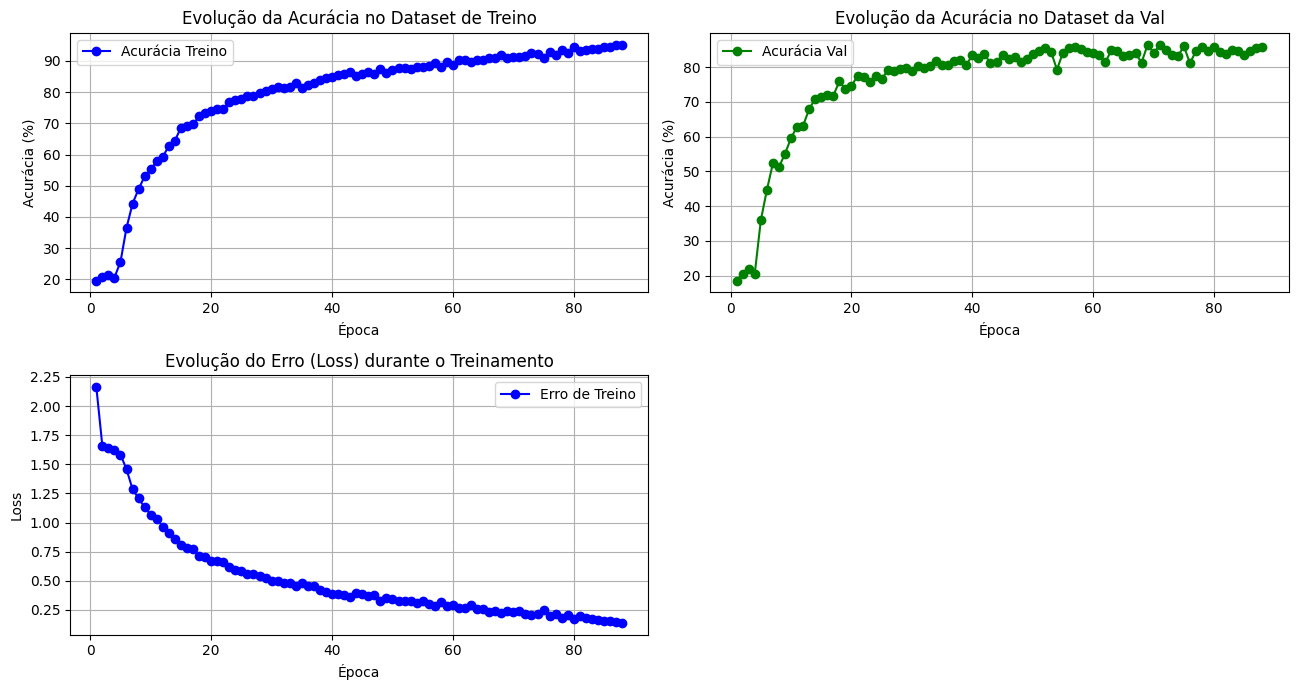

In [ ]:
plt.figure(figsize=(13, 7))

epocas = len(historico_perda_treino)

# Gráfico 1: Curva de Acurácia (Treino)
plt.subplot(2, 2, 1)
plt.plot(range(1, epocas + 1), historico_acuracia_treino, marker='o', color='blue', label='Acurácia Treino')
plt.title('Evolução da Acurácia no Dataset de Treino')
plt.ylabel('Acurácia (%)')
plt.xlabel('Época')
plt.grid(True)
plt.legend()

# Gráfico 2: Curva de Acurácia (Val)
plt.subplot(2, 2, 2)
plt.plot(range(1, epocas + 1), historico_acuracia_validacao, marker='o', color='green', label='Acurácia Val')
plt.title('Evolução da Acurácia no Dataset da Val')
plt.ylabel('Acurácia (%)')
plt.xlabel('Época')
plt.grid(True)
plt.legend()


# Gráfico 3: Curva de Perda (Treino)
plt.subplot(2, 2, 3)
plt.plot(range(1, epocas + 1), historico_perda_treino, marker='o', color='blue', label='Erro de Treino')
plt.title('Evolução do Erro (Loss) durante o Treinamento')
plt.ylabel('Loss')
plt.xlabel('Época')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("/content/model/best/acc_train_acc_val_loss.png", dpi=300, bbox_inches="tight")
plt.show()

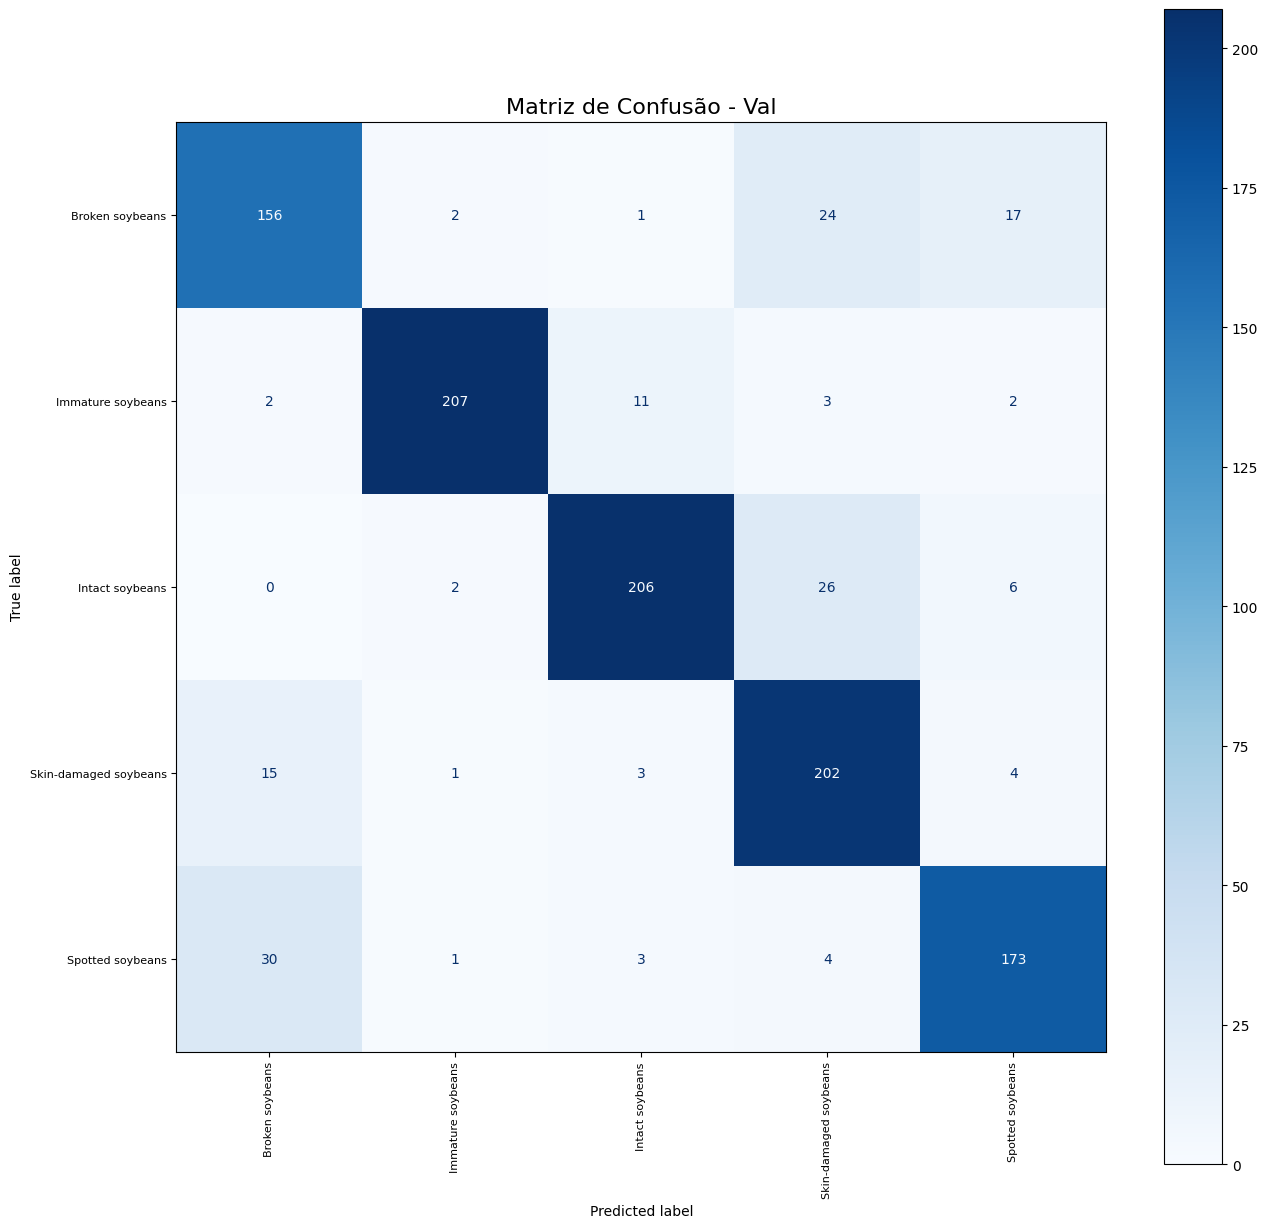

In [ ]:
# 1. Gera a matriz numérica pura
cm = confusion_matrix(todos_rotulos, todas_previsoes)

fig, ax = plt.subplots(figsize=(15, 15))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, xticks_rotation='vertical')

plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.title('Matriz de Confusão - Val', fontsize=16)

plt.savefig("/content/model/best/matrix_cf_val.png", dpi=300)

plt.show()

## 3.3 Teste

### 3.3.1 Metricas do melhor modelo

In [ ]:
modelo.load_state_dict(torch.load('model/best/melhor_modelo.pth'))

modelo.eval()

todos_rotulos_teste = []
todas_previsoes_teste = []

with torch.no_grad():
    for imagens, rotulos in loader_teste:
        imagens, rotulos = imagens.to(device), rotulos.to(device)
        saidas = modelo(imagens)
        _, previsoes = torch.max(saidas.data, 1)

        todos_rotulos_teste.extend(rotulos.cpu().numpy())
        todas_previsoes_teste.extend(previsoes.cpu().numpy())

acuracia_teste = accuracy_score(todos_rotulos_teste, todas_previsoes_teste) * 100
precisao_teste = precision_score(todos_rotulos_teste, todas_previsoes_teste, average='macro', zero_division=0)
recall_teste = recall_score(todos_rotulos_teste, todas_previsoes_teste, average='macro', zero_division=0)
f1_teste = f1_score(todos_rotulos_teste, todas_previsoes_teste, average='macro', zero_division=0)

print("=== Resultado Final no Conjunto de Teste ===")
print(f'Acurácia: {acuracia_teste:.2f}%')
print(f'Precisão (macro): {precisao_teste:.4f}')
print(f'Recall (macro): {recall_teste:.4f}')
print(f'F1-Score (macro): {f1_teste:.4f}')

with open("model/best/metricas_teste.txt", "w", encoding="utf-8") as f:
    f.write("=== Resultado Final no Conjunto de Teste ===\n")
    f.write(f"Acurácia: {acuracia_teste:.2f}%\n")
    f.write(f"Precisão (macro): {precisao_teste:.4f}\n")
    f.write(f"Recall (macro): {recall_teste:.4f}\n")
    f.write(f"F1-Score (macro): {f1_teste:.4f}\n")

=== Resultado Final no Conjunto de Teste ===
Acurácia: 90.29%
Precisão (macro): 0.9004
Recall (macro): 0.8989
F1-Score (macro): 0.8989


### 3.3.2 Matriz de Confusão do Melhor Modelo

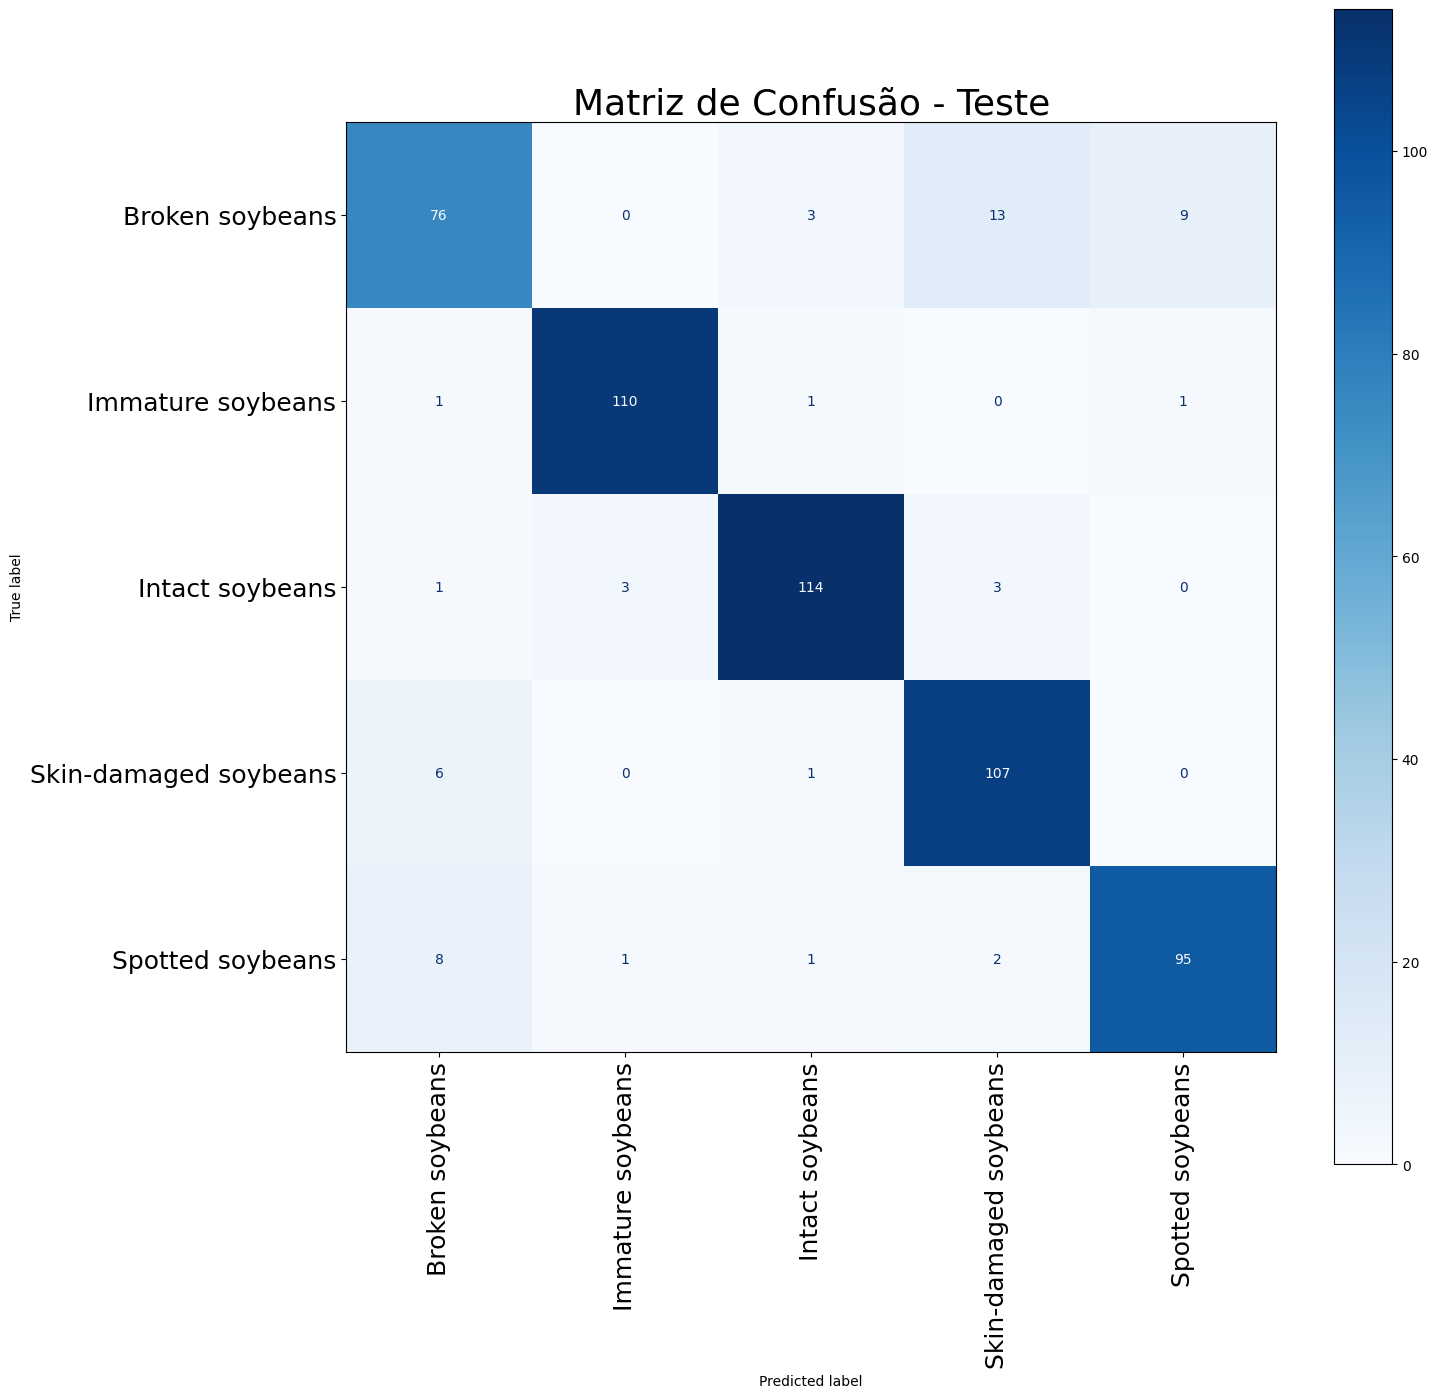

In [ ]:
# 1. Gera a matriz numérica pura
cm = confusion_matrix(todos_rotulos_teste, todas_previsoes_teste)

fig, ax = plt.subplots(figsize=(15, 15))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, xticks_rotation='vertical')

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Matriz de Confusão - Teste', fontsize=26)

plt.savefig("/content/model/best/matrix_cf_test.png", dpi=300)

plt.show()

# 4 Baixar o modelo

Caso queri fazer testes no futuro, é bom baixar o modelo

In [ ]:
!zip -r model.zip /content/model

updating: content/model/ (stored 0%)
updating: content/model/best/ (stored 0%)
updating: content/model/best/acc_train_acc_val_loss.png (deflated 17%)
updating: content/model/best/matrix_cf_val.png (deflated 38%)
updating: content/model/best/matrix_cf_test.png (deflated 40%)
updating: content/model/best/melhor_modelo.pth (deflated 7%)
updating: content/model/best/metricas_teste.txt (deflated 17%)


# 5 Carregar Modelo

In [ ]:
!unzip model.zip -d /

Archive:  model.zip
   creating: /content/model/
   creating: /content/model/best/
  inflating: /content/model/best/acc_train_acc_val_loss.png  
  inflating: /content/model/best/matrix_cf_val.png  
  inflating: /content/model/best/matrix_cf_test.png  
  inflating: /content/model/best/melhor_modelo.pth  
  inflating: /content/model/best/metricas_teste.txt  
